## Understanding Perceptron vs Logistic Regression

- **Perceptron trick** is key to understanding logistic regression.  
- The perceptron works similarly to logistic regression but has a limitation:  
  - It stops as soon as it finds a line that separates all points.  
  - In other words, it does not continue searching for the **optimal solution**.  
- **Logistic regression**, on the other hand, keeps optimizing the boundary using maximum likelihood, ensuring the best fit rather than just any separating line.


In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

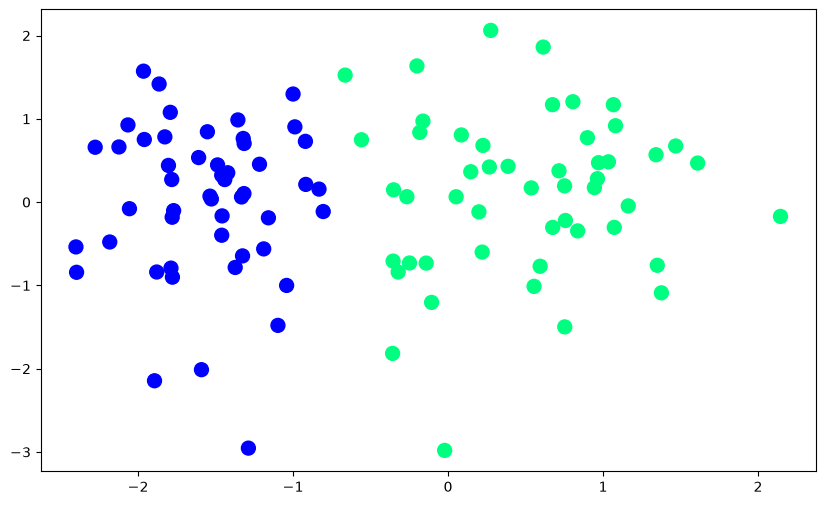

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [3]:
def Perception(x,y,lr,epochs):
    x=np.insert(x,0,1,axis=1)
    beta=np.ones(x.shape[1])
    for i in range(epochs):
        j = np.random.randint(x.shape[0])
        yHat=1 if np.dot(beta,x[j])>=0 else 0
        beta=beta+lr*(y[j]-yHat)*x[j]
    coef_=beta[1:]
    intercept_=beta[0]
    return (coef_,intercept_)

In [4]:
coef_,intercept_=Perception(X,y,0.1,1000)

In [5]:
m=-(coef_[0]/coef_[1])
c=-(intercept_/coef_[1])

In [6]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+c

In [7]:
from sklearn.linear_model import LogisticRegression
lr1=LogisticRegression()
lr1.fit(X,y)
coef_1,intercept_1=lr1.coef_,lr1.intercept_

In [ ]:
m1 = -(coef_1[0][0]/coef_1[0][1])
b1 = -(intercept_1/coef_1[0][1])

In [9]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

(-3.0, 2.0)

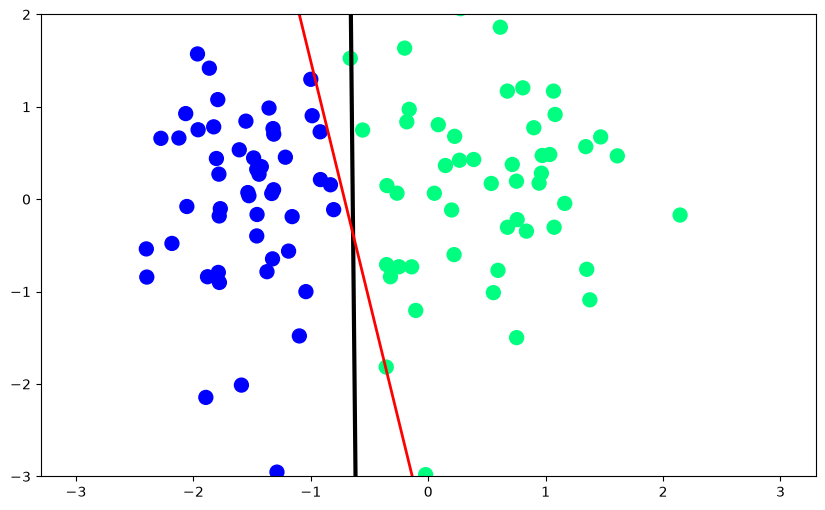

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.ylim(-3,2)